<a href="https://colab.research.google.com/github/Sunidhikusmi/Website-Traffic-Analysis/blob/main/WebsiteTrafficAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Website Traffic Analysis
Alfido Tech - Analytics Assessment


## Data Preparation
Clean dataset and convert date column.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/content/website_traffic.csv")

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df['date'] = pd.to_datetime(df['date'])
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


## Total Sessions
linkid used as session proxy

In [ ]:
total_sessions = df['linkid'].nunique()
print("Total Sessions:", total_sessions)

Total Sessions: 743


## Approximate Users
No user_id available. Geo-based uniqueness used

In [ ]:
approx_users = df[['country','city']].drop_duplicates().shape[0]
print("Approx Unique Users:", approx_users)

Approx Unique Users: 12155


## Bounce Rate
Sessions with only one event considered bounce.

In [ ]:
session_counts = df.groupby('linkid').size()

bounce_sessions = session_counts[session_counts == 1].count()

bounce_rate = (bounce_sessions / total_sessions) * 100

print("Bounce Rate:", round(bounce_rate,2), "%")

Bounce Rate: 8.61 %


## Average Session Duration

In [ ]:
session_time = df.groupby('linkid')['date'].agg(['min','max'])

session_time['duration'] = (session_time['max'] - session_time['min']).dt.seconds

avg_session_duration = session_time['duration'].mean()

print("Average Session Duration (seconds):", round(avg_session_duration,2))

Average Session Duration (seconds): 0.0


## Entry & Exit Events

In [ ]:
entry_events = df.sort_values('date').groupby('linkid').first()
exit_events = df.sort_values('date').groupby('linkid').last()

print("Top Entry Events:")
print(entry_events['event'].value_counts().head())

print("\nTop Exit Events:")
print(exit_events['event'].value_counts().head())

Top Entry Events:
event
pageview    511
click       170
preview      62
Name: count, dtype: int64

Top Exit Events:
event
pageview    497
click       187
preview      59
Name: count, dtype: int64


## Event Funnel

In [ ]:
funnel = df['event'].value_counts()

pageviews = funnel.get('pageview', 0)
clicks = funnel.get('click', 0)
previews = funnel.get('preview', 0)

ctr = (clicks / pageviews) * 100 if pageviews > 0 else 0
preview_rate = (previews / pageviews) * 100 if pageviews > 0 else 0

print("Click Through Rate:", round(ctr,2), "%")
print("Preview Conversion Rate:", round(preview_rate,2), "%")

Click Through Rate: 44.25 %
Preview Conversion Rate: 24.21 %


## Event Transition Flow

In [ ]:
df_sorted = df.sort_values(['linkid','date'])
df_sorted['next_event'] = df_sorted.groupby('linkid')['event'].shift(-1)

transitions = df_sorted.groupby(['event','next_event']).size().reset_index(name='count')

transitions.sort_values('count', ascending=False).head(10)

,event,next_event,count
4,pageview,pageview,66051
0,click,click,27719
8,preview,preview,14399
2,click,preview,2036
7,preview,pageview,2009
3,pageview,click,2008
1,click,pageview,780
6,preview,click,299
5,pageview,preview,213


## Traffic Distribution

Top Countries

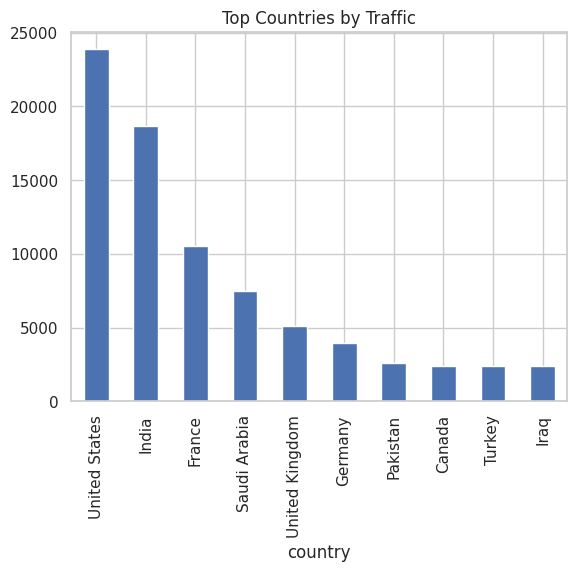

In [ ]:
top_countries = df['country'].value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title("Top Countries by Traffic")
plt.show()

Daily Traffic Trend

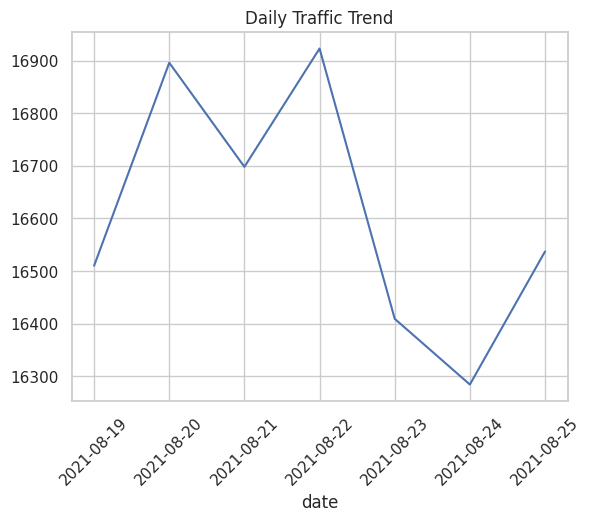

In [ ]:
daily_trend = df.groupby(df['date'].dt.date).size()

plt.figure()
daily_trend.plot()
plt.title("Daily Traffic Trend")
plt.xticks(rotation=45)
plt.show()

## Key Insights

- Traffic concentrated in top-performing countries

- Noticeable drop from pageview to click

- High bounce sessions present engagement gap

- Certain event transitions dominate user journeys

- Traffic fluctuates across specific dates

## Recommendations for Alfido Tech

- Optimize call-to-action to improve pageview → click conversion

- Improve engagement on high-bounce sessions

- Focus marketing efforts on top-performing countries

- Retarget users who click but don’t preview

- Increase campaigns during high-traffic days

## Assumptions & Limitations

Dataset does not contain explicit session_id or user_id.
linkid used as session proxy.
User estimation based on geo-level uniqueness.

## Conclusion

The analysis identifies behavioral patterns, engagement gaps, and geographic concentration. Optimizing early-stage interaction and targeting high-performing regions can significantly improve conversion performance for Alfido Tech.